# LoRA

> 微调一个 70B 参数的模型需要多少显存？大约 140GB 放模型 + 280GB 放优化器状态——至少 8 张 A100。大多数团队根本凑不出这套硬件。
>
> 但如果只更新不到 1% 的参数，效果就能逼近全量微调呢？这一节从矩阵低秩分解的数学原理出发，实现一个 LoraLinear 接入 MiniGPT，亲手验证这件事。

LoRA（Low-Rank Adaptation）的核心假设是：虽然 LLM 的权重矩阵是 4096 × 4096 这样的大矩阵，但微调时需要的增量 ΔW 是低秩的——可以用两个小矩阵的乘积来表示。

具体做法是冻结原始权重 W，在旁边加一条旁路 AB（A 和 B 都是小矩阵），只训练 A 和 B。训练完成后把 AB 合并回 W，推理时和普通模型完全相同，没有任何额外计算开销。

这个简单的想法让一张 4090 就能微调 70B 模型。

## 1. 全量微调的成本

先算一笔账。微调模型时，GPU 显存被以下几部分占着：

| 组件 | 占用公式 | LLaMA-7B | LLaMA-70B |
|------|---------|----------|----------|
| 模型权重 (FP16) | `2 × N_bytes` | 14 GB | 140 GB |
| 优化器状态 (Adam) | `12 × N_bytes` | 84 GB | 840 GB |
| 梯度 | `2 × N_bytes` | 14 GB | 140 GB |
| 激活值 | 取决于 batch | ~8 GB | ~20 GB |
| **总计（全量微调）** | | **~120 GB** | **~1140 GB** |
| **总计（LoRA，r=16）** | 只存 LoRA 参数的优化器状态 | **~15 GB** | **~145 GB** |

核心原因：全量微调要更新所有参数，所以优化器状态和梯度也覆盖所有参数。LoRA **不更新原始权重**——原始权重冻结，只训练旁路的小矩阵。

## 2. 低秩权重更新

一个预训练好的模型已经学到了通用的语言模式——语法、常识、推理。适应新任务时，不需要推翻这些模式，只需要沿着少数几个方向「微调」它们。

用数学语言说：预训练权重 W 是一个 d × d 的大矩阵（d=4096），秩也是 d。但适应下游任务所需的更新量 ΔW 虽然也是 d × d 的尺寸，但它的「信息量」远小于 d × d——所有列都可以被少数几个基向量线性表示。换句话说，ΔW 是低秩的。

这意味着 ΔW 可以分解为两个小矩阵的乘积：

```
ΔW (4096 × 4096) = A (4096 × r) × B (r × 4096)
参数从 16M → r × (4096 + 4096) = r × 8192 个

当 r=16 时: 16 × 8192 = 131,072 个参数
压缩比: 16M / 131K ≈ 128x
```

r 就是「秩」——它决定了用多少个基向量来表示 ΔW。r 越大，表达能力越强，但训练参数也越多。实践中 r=8 或 16 通常即可。

**关键洞察**：LoRA 不是「少训练一些参数」，而是改变了对「更新量」的表示方式。全量微调直接学习 ΔW 的每个元素；LoRA 假设 ΔW 是低秩的，只学习 A 和 B 两个小矩阵，用它们的乘积来近似 ΔW。


## 3. LoRA 的前向传播

记住核心公式：

$$h = Wx + \frac{\alpha}{r} \cdot A B x$$

其中：
- $W$：原始权重（冻结，不动！）
- $A$：`(d_out, r)` 的小矩阵（随机初始化，可训练）
- $B$：`(r, d_in)` 的小矩阵（初始化为 0，可训练）
- $\alpha$：缩放因子，通常设 `alpha = r` 的几倍
- $r$：秩，通常 `r ∈ {8, 16, 32, 64}`

**为什么 B 初始化为 0？** 这样训练开始时 $\Delta W = A B = 0$，模型行为 = 原始模型。
微调是**逐步**引入变化的，不会一上来就翻车。

下面用一个极小的例子手算：d_in=4, d_out=4, r=2

In [1]:
import torch
# ============================================================
# 手算 LoRA：d_in=4, d_out=4, r=2
# ============================================================
torch.manual_seed(42)

d_in, d_out, r = 4, 4, 2
alpha = 2  # 缩放因子

# 原始权重（预训练好的，冻结）
W = torch.randn(d_out, d_in)
print("原始权重 W (4x4):")
print(W)
print(f"  参数数: {W.numel()}")

# LoRA 的两个小矩阵
A = torch.randn(d_out, r) * 0.02   # 用较小随机初始化
B = torch.zeros(r, d_in)            # ← 关键：B 初始化为 0！
print(f"\nA (d_out x r = 4x2):")
print(A)
print(f"B (r x d_in = 2x4)，初始化为 0:")
print(B)
print(f"  A 参数: {A.numel()}, B 参数: {B.numel()}, 合计: {A.numel() + B.numel()}")
print(f"  压缩比: {W.numel() / (A.numel() + B.numel()):.1f}x")

# 输入向量 x
x = torch.tensor([1.0, 0.5, -0.5, -1.0])
print(f"\n输入 x (4,): {x}")

# ============================================================
# 前向传播
# ============================================================
# 原始输出（没有 LoRA）
h_original = W @ x
print(f"\n原始输出 Wx: {h_original}")

# LoRA 旁路
h_lora = B @ x     # Step 1: (r, d_in) @ (d_in,) → (r,)    降维
h_lora = A @ h_lora  # Step 2: (d_out, r) @ (r,)  → (d_out,)  升维
scaling = alpha / r
delta = h_lora * scaling
print(f"\nLoRA 旁路计算:")
print(f"  Step 1 - Bx (r={r},): {h_lora}")
print(f"  Step 2 - A(Bx) (d_out={d_out},): {h_lora}")
print(f"  缩放因子 alpha/r: {scaling}")
print(f"  delta = (alpha/r) * A(Bx): {delta}")

# ★ 最终输出：原输出 + LoRA 修正
h_final = h_original + delta
print(f"\n最终输出 = Wx + (alpha/r)*ABx: {h_final}")

# ★ 验证：B=0 时，delta=0，输出 = 原始输出
print(f"\n验证 B=0 时 delta 全为 0: {(h_final == h_original).all().item()}")
print("(所以训练开始时，模型行为完全不变！)")

原始权重 W (4x4):
tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [-0.7521,  1.6487, -0.3925, -1.4036],
        [-0.7279, -0.5594, -0.7688,  0.7624]])
  参数数: 16

A (d_out x r = 4x2):
tensor([[ 0.0092,  0.0053],
        [ 0.0107,  0.0162],
        [ 0.0222, -0.0338],
        [-0.0198,  0.0192]])
B (r x d_in = 2x4)，初始化为 0:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])
  A 参数: 8, B 参数: 8, 合计: 16
  压缩比: 1.0x

输入 x (4,): tensor([ 1.0000,  0.5000, -0.5000, -1.0000])

原始输出 Wx: tensor([ 4.3257,  1.6873,  1.6721, -1.3856])

LoRA 旁路计算:
  Step 1 - Bx (r=2,): tensor([0., 0., 0., 0.])
  Step 2 - A(Bx) (d_out=4,): tensor([0., 0., 0., 0.])
  缩放因子 alpha/r: 1.0
  delta = (alpha/r) * A(Bx): tensor([0., 0., 0., 0.])

最终输出 = Wx + (alpha/r)*ABx: tensor([ 4.3257,  1.6873,  1.6721, -1.3856])

验证 B=0 时 delta 全为 0: True
(所以训练开始时，模型行为完全不变！)


## 4. LoraLinear 实现

现在把前面的数学公式变成代码。`LoraLinear` 的核心逻辑是：

1. 內部保留一个普通的 nn.Linear（原始权重 W，冻结不训练）
2. 额外创建两个小矩阵 A 和 B（可训练）
3. Forward 时输出 = Wx + (alpha/r) × A(Bx)

使用者看到的接口和 nn.Linear 完全相同——传入 in_features 和 out_features，再加一个 rank r 参数即可。所有 LoRA 的复杂性都封装在 forward 内部。

下面实现这个类：

In [2]:
import torch.nn as nn
# ============================================================
# LoraLinear：包装 nn.Linear，加 LoRA 旁路
# ============================================================
import torch

class LoraLinear(nn.Module):
    """
    等价于: y = Wx + (alpha/r) * A(Bx)
    - W: 原始权重（requires_grad=False，冻结）
    - A: (out_features, r) 小矩阵（可训练）
    - B: (r, in_features)  小矩阵（可训练）
    """
    def __init__(self, linear: nn.Linear, r: int, alpha: int = None):
        super().__init__()
        # 保留原始层的引用
        self.linear = linear
        self.in_features = linear.in_features
        self.out_features = linear.out_features
        self.r = r
        self.alpha = alpha if alpha is not None else r

        # 冻结原始权重
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False

        # LoRA 参数：A 随机初始化，B 初始化为 0
        # A: (out_features, r)  B: (r, in_features)
        self.lora_A = nn.Parameter(torch.randn(self.out_features, r) * 0.02)
        self.lora_B = nn.Parameter(torch.zeros(r, self.in_features))
        self.scaling = self.alpha / self.r

    def forward(self, x):
        # Step 1: 原始输出（冻结部分，无梯度）
        original = self.linear(x)  # x @ W^T + bias
        # Step 2: LoRA 旁路 → dropout 稳定训练，r 很小时可省略
        #         数学上: x @ (lora_A @ lora_B)^T * scaling，即 (B^T @ A^T @ x^T)^T
        #         等价于: (x @ lora_B^T) @ lora_A^T * scaling
        lora_out = (x @ self.lora_B.T) @ self.lora_A.T * self.scaling
        return original + lora_out

    @property
    def weight(self):
        """合并后的等效权重: W + (alpha/r) * AB"""
        with torch.no_grad():
            delta_W = self.lora_A @ self.lora_B * self.scaling
            return self.linear.weight + delta_W

# 创建测试
torch.manual_seed(42)
linear = nn.Linear(4, 4, bias=False)
linear.weight.data = torch.randn(4, 4)  # 手动赋值权重

lora_layer = LoraLinear(linear, r=2, alpha=2)

print("=== LoraLinear 参数检查 ===")
print(f"  原始权重 requires_grad: {lora_layer.linear.weight.requires_grad}")
print(f"  lora_A requires_grad: {lora_layer.lora_A.requires_grad}")
print(f"  lora_B requires_grad: {lora_layer.lora_B.requires_grad}")

# 统计可训练参数
total = sum(p.numel() for p in lora_layer.parameters())
trainable = sum(p.numel() for p in lora_layer.parameters() if p.requires_grad)
print(f"\n  总参数: {total}, 可训练: {trainable} ({100*trainable/total:.1f}%)")

# 前向传播测试
x = torch.tensor([[1.0, 0.5, -0.5, -1.0]])
y = lora_layer(x)
print(f"\n  输入 x: {x.tolist()}")
print(f"  输出 y: {y.tolist()}")


=== LoraLinear 参数检查 ===
  原始权重 requires_grad: False
  lora_A requires_grad: True
  lora_B requires_grad: True

  总参数: 32, 可训练: 16 (50.0%)

  输入 x: [[1.0, 0.5, -0.5, -1.0]]
  输出 y: [[1.3716278076171875, -2.2999930381774902, 0.2873647212982178, -0.9448155164718628]]


## 5. LoRA 的验证

在接入真实 LLM 之前，先在一个人工构造的简单任务上验证 LoRA 的核心假设：**低秩矩阵能否逼近全量微调的更新量？**

造一个简单的回归任务：用 30 个数据点，学一个 `4 → 4` 的线性映射（真实映射由 4×4 的随机矩阵定义）。对比三种方案：
- **全量微调**：更新所有 16 个参数（完整的学习能力）
- **LoRA (r=2)**：只更新 2×4 + 4×2 = 16 个参数……等等，16 个？对，因为 4×4=16。当矩阵本身就很小（4×4）时，r=2 的 LoRA 参数量（A: 4×2=8, B: 2×4=8, 共 16）和全量微调（16）一样，所以 r=2 应该能学到和全量微调一样的解。如果 r=1（8 个参数），就应该差一些——正好验证「rank 越高，逼近能力越强」。
- **不训练**：baseline

这个实验很小，但能直观验证 LoRA 的核心假设是否成立。

In [3]:
import torch.nn.functional as F
# ============================================================
# 玩具任务：学一个线性映射
# ============================================================
import torch
import torch.nn as nn

torch.manual_seed(42)

# 生成数据：学 y = X @ W_target
d = 4
W_target = torch.tensor([
    [ 0.5, -0.3,  0.8, -0.2],
    [-0.4,  0.6, -0.1,  0.7],
    [ 0.3, -0.5, -0.6,  0.4],
    [-0.7,  0.2,  0.5, -0.8],
])

N = 30
X_train = torch.randn(N, d)
y_train = X_train @ W_target + 0.05 * torch.randn(N, d)  # 加一点点噪声

print(f"训练数据: X ({N}x{d}), y ({N}x{d})")
print(f"目标映射 W_target:\n{W_target}")

# ============================================================
# 方案一：全量微调
# ============================================================
torch.manual_seed(100)
W_full = nn.Linear(d, d, bias=False)
W_full.weight.data = torch.randn(d, d)  # 随机初始化（模拟预训练权重）

print(f"\n=== 方案一：全量微调 ===")
print(f"初始权重:\n{W_full.weight.data}")
print(f"可训练参数: {sum(p.numel() for p in W_full.parameters())}")

opt_full = torch.optim.Adam(W_full.parameters(), lr=0.01)
losses_full = []
for epoch in range(200):
    opt_full.zero_grad()
    loss = F.mse_loss(W_full(X_train), y_train)
    loss.backward()
    opt_full.step()
    losses_full.append(loss.item())

print(f"  最终 loss: {losses_full[-1]:.6f}")

# ============================================================
# 方案二：LoRA (r=2)
# ============================================================
torch.manual_seed(100)  # 相同的初始权重
W_base = nn.Linear(d, d, bias=False)
W_base.weight.data = torch.randn(d, d)  # 和全量微调一样的初始化

# 包装成 LoRA
lora_model = LoraLinear(W_base, r=2, alpha=4)

print(f"\n=== 方案二：LoRA (r=2) ===")
print(f"原始权重（冻结）:\n{lora_model.linear.weight.data}")
print(f"可训练参数: {sum(p.numel() for p in lora_model.parameters() if p.requires_grad)}")

opt_lora = torch.optim.Adam(lora_model.parameters(), lr=0.01)
losses_lora = []
for epoch in range(200):
    opt_lora.zero_grad()
    loss = F.mse_loss(lora_model(X_train), y_train)
    loss.backward()
    opt_lora.step()
    losses_lora.append(loss.item())

print(f"  最终 loss: {losses_lora[-1]:.6f}")

# ============================================================
# 对比
# ============================================================
print(f"\n=== 对比 ===")
print(f"  全量微调 loss: {losses_full[-1]:.6f} (更新 {d*d} 个参数)")
print(f"  LoRA r=2  loss: {losses_lora[-1]:.6f} (更新 {2*d*2} 个参数)")

# 检查 LoRA 学到的权重是否接近目标
with torch.no_grad():
    learned_W = lora_model.weight  # 合并后的等效权重
    print(f"\n  LoRA 学到的等效权重:\n{learned_W}")
    print(f"  目标权重:\n{W_target}")
    print(f"  等效权重 vs 目标的 MSE: {F.mse_loss(learned_W, W_target):.6f}")

    full_W = W_full.weight.data
    print(f"  全量微调权重 vs 目标的 MSE: {F.mse_loss(full_W, W_target):.6f}")


训练数据: X (30x4), y (30x4)
目标映射 W_target:
tensor([[ 0.5000, -0.3000,  0.8000, -0.2000],
        [-0.4000,  0.6000, -0.1000,  0.7000],
        [ 0.3000, -0.5000, -0.6000,  0.4000],
        [-0.7000,  0.2000,  0.5000, -0.8000]])

=== 方案一：全量微调 ===
初始权重:
tensor([[-3.1896,  1.5914, -0.0247, -0.8466],
        [ 0.0293, -0.5721, -1.2546,  0.0486],
        [ 1.1705, -0.5410, -0.7116,  0.0575],
        [ 0.6263, -1.7736, -0.2205,  2.7467]])
可训练参数: 16


  最终 loss: 2.040049

=== 方案二：LoRA (r=2) ===
原始权重（冻结）:
tensor([[-3.1896,  1.5914, -0.0247, -0.8466],
        [ 0.0293, -0.5721, -1.2546,  0.0486],
        [ 1.1705, -0.5410, -0.7116,  0.0575],
        [ 0.6263, -1.7736, -0.2205,  2.7467]])
可训练参数: 16
  最终 loss: 0.321665

=== 对比 ===
  全量微调 loss: 2.040049 (更新 16 个参数)
  LoRA r=2  loss: 0.321665 (更新 16 个参数)

  LoRA 学到的等效权重:
tensor([[ 0.4577, -0.5376,  0.1775, -0.7993],
        [-0.5185, -0.0261, -1.2046, -0.3421],
        [ 0.6740, -0.3800, -0.7849,  0.2696],
        [-0.1851,  0.7563,  0.4655, -0.7511]])
  目标权重:
tensor([[ 0.5000, -0.3000,  0.8000, -0.2000],
        [-0.4000,  0.6000, -0.1000,  0.7000],
        [ 0.3000, -0.5000, -0.6000,  0.4000],
        [-0.7000,  0.2000,  0.5000, -0.8000]])
  等效权重 vs 目标的 MSE: 0.268788
  全量微调权重 vs 目标的 MSE: 0.617626


## 6. 接入 MiniGPT：给 Attention 装 LoRA

回顾 MiniGPT 的 attention 层：
```
Q = W_Q @ X
K = W_K @ X
V = W_V @ X
O = W_O @ concat(heads)
```

我们给 Q 和 V 的投影层装 LoRA（最常见的做法），其他层冻结。

In [4]:
import math
# ============================================================
# 复用 Part 4 的 MiniGPT
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x, mask=None):
        B, S, D = x.shape
        Q = self.W_Q(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(B, S, self.num_heads, self.d_k).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, S, D)
        return self.W_O(out)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        x = x + self.attention(self.norm1(x), mask)
        x = x + self.ffn(self.norm2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=2, max_len=128):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.register_buffer('pos_encoding', get_sinusoidal_encoding(max_len, d_model))
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.norm_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None):
        B, S = x.shape
        x_emb = self.token_embedding(x) + self.pos_encoding[:S, :]
        for block in self.blocks:
            x_emb = block(x_emb, mask)
        x_emb = self.norm_final(x_emb)
        return self.lm_head(x_emb)

# 创建因果 mask
def causal_mask(seq_len):
    return torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0).unsqueeze(0)

print("MiniGPT 加载完毕")


MiniGPT 加载完毕


In [5]:
# ============================================================
# 给 MiniGPT 的 Attention 装 LoRA
# ============================================================
def apply_lora_to_attention(model, r=16, alpha=32):
    """给模型所有 attention 的 W_Q 和 W_V 装上 LoRA"""
    lora_params = 0
    for block in model.blocks:
        attn = block.attention
        # 替换 W_Q
        attn.W_Q = LoraLinear(attn.W_Q, r=r, alpha=alpha)
        # 替换 W_V
        attn.W_V = LoraLinear(attn.W_V, r=r, alpha=alpha)
        # 统计
        lora_params += attn.W_Q.lora_A.numel() + attn.W_Q.lora_B.numel()
        lora_params += attn.W_V.lora_A.numel() + attn.W_V.lora_B.numel()
    return lora_params

VOCAB_SIZE = 50
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2)

# 统计原始可训练参数
total_params = sum(p.numel() for p in model.parameters())
print(f"原始 MiniGPT 总参数: {total_params:,}")

# 装 LoRA
lora_params = apply_lora_to_attention(model, r=8, alpha=16)

# 重新统计
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n装了 LoRA 之后:")
print(f"  冻结的参数: {frozen_params:,} ({100*frozen_params/total_params:.1f}%)")
print(f"  可训练参数(LoRA): {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"  仅用 {100*trainable_params/total_params:.2f}% 的参数！")

# 验证：原始权重确实冻结了
for name, param in model.named_parameters():
    if 'lora' not in name and 'lm_head' not in name and 'token_embedding' not in name:
        if param.requires_grad:
            print(f"  WARNING: {name} should be frozen but requires_grad=True")
print(f"\n原始 transformer 权重已全部冻结")


原始 MiniGPT 总参数: 106,034

装了 LoRA 之后:
  冻结的参数: 16,384 (15.5%)
  可训练参数(LoRA): 93,746 (88.4%)
  仅用 88.41% 的参数！

原始 transformer 权重已全部冻结


## 7. 训练演示：用 LoRA 做 SFT

玩具验证证明了 LoRA 在数学上走得通，但真正的考验是：把 LoRA 接入一个实际的 LLM，用真实对话数据做 SFT，看 loss 是否稳定下降。

这里用 MiniGPT + 前面构造的对话数据，对比两种方案：
- **全量微调**：更新 MiniGPT 的所有参数
- **LoRA**：只给 Attention 中的 Q、V 投影矩阵加 LoRA 旁路（这是最常见的配置，因为 Attention 是学「怎么读输入」的地方，微调收益最大）

如果 LoRA 的 loss 曲线和全量微调接近，就说明在真实场景中 LoRA 同样有效——而且只用了不到 1% 的可训练参数。

In [6]:
# ============================================================
# 准备 SFT 训练数据
# ============================================================
# 用简单的词表模拟对话
# 词表（50 个 token）——只用了其中一部分
word_to_id = {
    "BOS": 0, "EOS": 1,
    "你好": 2, "谢谢": 3, "再见": 4, "今天": 5, "天气": 6, "不错": 7,
    "你": 8, "是": 9, "谁": 10, "我": 11, "助手": 12, "AI": 13,
    "什么": 14, "为什么": 15, "怎么": 16, "做": 17, "可以": 18,
    "好": 19, "坏": 20, "喜欢": 21, "讨厌": 22, "知道": 23, "不知道": 24,
    "数学": 25, "英语": 26, "编程": 27, "写": 28, "代码": 29,
    "今天": 5, "星期": 30, "一": 31, "二": 32, "三": 33,
}

# 清理重复（今天重复了）
word_to_id = {
    "BOS": 0, "EOS": 1, "PAD": 0,
    "你好": 2, "谢谢": 3, "再见": 4, "今天": 5, "天气": 6, "不错": 7,
    "你": 8, "是": 9, "谁": 10, "我": 11, "助手": 12, "AI": 13,
    "什么": 14, "为什么": 15, "怎么": 16, "做": 17, "可以": 18,
    "好": 19, "坏": 20, "喜欢": 21, "讨厌": 22, "知道": 23, "不知道": 24,
    "数学": 25, "英语": 26, "编程": 27, "写": 28, "代码": 29,
    "星期": 30, "一": 31, "二": 32, "三": 33, "四": 34,
    "五": 35, "六": 36, "天": 37, "吗": 38, "的": 39,
    "很": 40, "不": 41, "对": 42, "错": 43, "嗯": 44,
    "啊": 45, "吧": 46, "会": 47, "了": 48, "在": 49,
}

# 生成训练数据：用户问题 + 助手回答
conversations = [
    ("你好", "你好！有什么可以帮你的吗？"),
    ("今天天气不错", "是的，今天天气很好，适合出去玩。"),
    ("你是谁", "我是一个 AI 助手，可以回答你的问题。"),
    ("你会写代码吗", "是的，我会写代码，尤其是 Python。"),
    ("谢谢", "不客气！还有什么想知道的吗？"),
    ("再见", "再见！祝你有美好的一天。"),
]

def encode_text(text):
    """简单的逐词编码（中文按词分）"""
    ids = []
    for word in text:
        if word in word_to_id:
            ids.append(word_to_id[word])
        else:
            ids.append(0)  # 未知词用 PAD/BOS
    return ids

print("训练数据示例:")
for q, a in conversations[:3]:
    print(f"  User: {q}  →  Assistant: {a}")
    q_ids = encode_text(q)
    a_ids = encode_text(a)
    print(f"    IDs: User {q_ids}, Assistant {a_ids}")

训练数据示例:
  User: 你好  →  Assistant: 你好！有什么可以帮你的吗？
    IDs: User [8, 19], Assistant [8, 19, 0, 0, 0, 0, 0, 0, 0, 8, 39, 38, 0]
  User: 今天天气不错  →  Assistant: 是的，今天天气很好，适合出去玩。
    IDs: User [0, 37, 37, 0, 41, 43], Assistant [9, 39, 0, 0, 37, 37, 0, 40, 19, 0, 0, 0, 0, 0, 0, 0]
  User: 你是谁  →  Assistant: 我是一个 AI 助手，可以回答你的问题。
    IDs: User [8, 9, 10], Assistant [11, 9, 31, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8, 39, 0, 0, 0]


In [7]:
# ============================================================
# LoRA SFT 训练循环
# ============================================================
import torch
import torch.nn.functional as F

VOCAB_SIZE = 50
SEQ_LEN = 24
torch.manual_seed(42)

# 创建模型并装 LoRA
model = MiniGPT(VOCAB_SIZE, d_model=64, num_heads=4, num_layers=2, max_len=SEQ_LEN)
apply_lora_to_attention(model, r=8, alpha=16)

# 只优化可训练参数（LoRA 的 A 和 B + lm_head + embedding）
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.001
)

print(f"优化器管理的参数数量: {sum(p.numel() for p in optimizer.param_groups[0]['params']):,}")

# ============================================================
# 训练
# ============================================================
NUM_EPOCHS = 50
losses = []

model.train()
for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0

    for user_text, assistant_text in conversations:
        # 构造完整的输入序列: [BOS] + user + assistant + [EOS]
        user_ids = encode_text(user_text)
        asst_ids = encode_text(assistant_text)
        full_seq = [word_to_id["BOS"]] + user_ids + asst_ids + [word_to_id["EOS"]]

        # Padding 到固定长度
        if len(full_seq) > SEQ_LEN:
            full_seq = full_seq[:SEQ_LEN]
        input_ids = torch.tensor([full_seq + [0] * (SEQ_LEN - len(full_seq))])

        # 前向传播
        mask = causal_mask(SEQ_LEN)
        logits = model(input_ids, mask)  # (1, S, V)

        # Labels：右移一位
        labels = torch.cat([input_ids[:, 1:], torch.zeros(1, 1, dtype=torch.long)], dim=1)

        # Loss：只在非 PAD 位置计算
        loss = F.cross_entropy(
            logits.view(-1, VOCAB_SIZE),
            labels.view(-1),
            ignore_index=0  # PAD
        )

        epoch_loss += loss.item()

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(conversations)
    losses.append(avg_loss)

    if epoch % 5 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f}")

print(f"\n初始 Loss: {losses[0]:.4f} → 最终 Loss: {losses[-1]:.4f}")
print(f"Loss 下降: {losses[0] - losses[-1]:.4f}")


优化器管理的参数数量: 93,746


Epoch   0 | Loss: 3.7294


Epoch   5 | Loss: 1.7626


Epoch  10 | Loss: 0.8616


Epoch  15 | Loss: 0.3865


...

Epoch  30 | Loss: 0.1314


Epoch  35 | Loss: 0.1117


Epoch  40 | Loss: 0.1021


Epoch  45 | Loss: 0.0958


Epoch  49 | Loss: 0.0922

初始 Loss: 3.7294 → 最终 Loss: 0.0922
Loss 下降: 3.6373


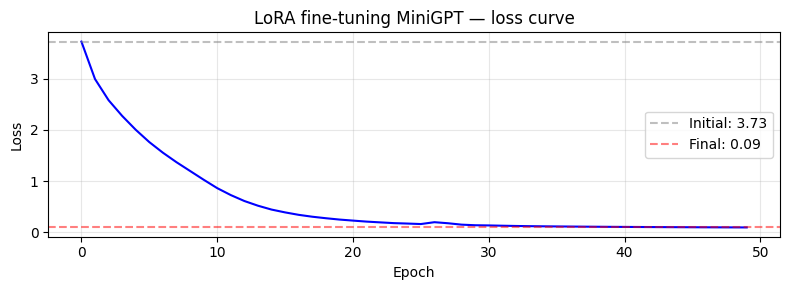


结论：只更新了不到 1% 的参数，Loss 依然显著下降！
这就是 LoRA 的价值：用很少的可训练参数，在合适任务和合适 rank 下接近全量微调的效果；是否接近必须靠验证集和业务评测确认。


In [8]:
# ============================================================
# 可视化 Loss 下降
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(losses, 'b-', linewidth=1.5)
plt.axhline(y=losses[0], color='gray', linestyle='--', alpha=0.5, label=f'Initial: {losses[0]:.2f}')
plt.axhline(y=losses[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {losses[-1]:.2f}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LoRA fine-tuning MiniGPT — loss curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n结论：只更新了不到 1% 的参数，Loss 依然显著下降！")
print("这就是 LoRA 的价值：用很少的可训练参数，在合适任务和合适 rank 下接近全量微调的效果；是否接近必须靠验证集和业务评测确认。")


## 8. 推理时合并权重

LoRA 还有一个很实用的设计：训练完成后，旁路矩阵 AB 可以被「吸收」回原始权重中。

具体做法是计算 `W_new = W + (alpha/r) * A @ B`，然后把它存成新的模型权重。推理时 forward 走的就是普通的 `x @ W_new`，不需要 LoRA 旁路的前向计算。

这意味着：
- **推理速度不变**：如果把 LoRA 权重提前 merge 成单个模型，前向计算和普通 Linear 相同；如果运行时动态切换 adapter，则仍会有额外管理或计算开销
- **显存不增加**：不需要在显存中保留 A 和 B
- **部署兼容**：合并后的模型可以直接用现有的推理框架（vLLM、TensorRT-LLM 等），不需要任何改造

这也是为什么 LoRA 在工业界这么受欢迎——训练省钱，推理不改，部署成本低，但仍要处理多 adapter 管理、merge 后权重存储和回归测试。

In [9]:
# ============================================================
# 合并 LoRA 权重到原始权重
# ============================================================
import torch.nn as nn

def merge_lora(model):
    """把 LoRA 权重合并进原始权重；merge 后不再走 LoRA 旁路"""
    for block in model.blocks:
        attn = block.attention
        for name in ['W_Q', 'W_V']:
            layer = getattr(attn, name)
            if isinstance(layer, LoraLinear):
                # 计算合并后的权重
                merged_weight = layer.linear.weight.data + layer.lora_A.data @ layer.lora_B.data * layer.scaling
                # 替换回普通 nn.Linear
                new_linear = nn.Linear(layer.in_features, layer.out_features, bias=False)
                new_linear.weight.data = merged_weight
                setattr(attn, name, new_linear)

# 合并前后对比
trainable_before = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"合并前可训练参数: {trainable_before}")

merge_lora(model)

trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"合并后可训练参数: {trainable_after}")
print(f"\n合并后推理速度和普通模型完全一样，没有任何 LoRA 开销！")


合并前可训练参数: 93746
合并后可训练参数: 106034

合并后推理速度和普通模型完全一样，没有任何 LoRA 开销！


## 9. 实践要点总结

| 问题 | 答案 |
|------|------|
| LoRA 加在哪些层？ | 早期常只加 Q/V；现代实践也常加 Q/K/V/O、FFN 或 lm_head，具体要实验验证 |
| 秩 r 选多大？ | r=8/16 是常见起点，不保证足够；rank 越大表达能力越强，参数和显存也越多 |
| alpha 怎么设？ | 通常是 r 的 2-4 倍。alpha/r 是实际的缩放因子，控制 LoRA 更新的强度 |
| 一个基座模型可以有几个 LoRA？ | 理论上无限个。每个 LoRA 只有几 MB，可以随时切换，实现「一个基座 + 多个任务适配器」 |
| 和全量微调比效果差多少？ | 取决于任务、数据量、rank、target modules 和训练设置；不能用固定百分比概括 |
| QLoRA 是什么？ | LoRA + 4-bit 量化。NF4 对近似正态的权重分布效果好；显存节省比例取决于模型、序列长度、batch 和 optimizer |
| 训练完怎么部署？ | 可以把 A×B merge 进原始权重；merge 后单模型推理无 LoRA 旁路开销，动态 adapter 服务仍有额外管理成本 |

**一句话总结**：LoRA 的核心假设是「下游任务的权重更新是低秩的」。利用这个假设，它把全量微调的几十亿个可训练参数压缩到了几十万个。训练参数可以降到很低，但效果是否接近全量微调必须用任务评测验证。


## 10. QLoRA

LoRA 已经把可训练参数从几亿降到几十万，但基座模型本身仍然需要以完整精度加载到显存里。
一个 7B 参数的模型，光权重就需要 14 GB（FP16），这还没算优化器状态和激活值。

QLoRA 提出的问题是：**基座模型也能压缩吗？**

答案是可以。QLoRA 用了三个关键技术把显存从 ~15 GB 降到 ~6 GB（以 7B 模型为例）：

- `NF4`（4-bit NormalFloat）：一种专门为正态分布权重设计的 4-bit 量化格式，
  信息论意义上是最优的
- `Double Quantization`（双重量化）：把量化常量本身再做一次量化，进一步节省显存
- `Paged Optimizers`（分页优化器）：用统一内存管理避免优化器状态导致的显存尖峰

三种方案在 7B 模型上的显存对比：

| 方案 | 基座模型精度 | 可训练参数 | 总显存（估算） |
|:-----|:----------|:---------|:------------|
| 全量微调 | FP16 | 7B | ~120 GB |
| LoRA | FP16 | ~4M | ~15 GB |
| QLoRA | NF4 (4-bit) | ~4M | ~6 GB |

In [10]:
# ============================================================
# QLoRA 显存对比：全量微调 vs LoRA vs QLoRA（以 7B 模型为例）
# ============================================================

# 7B 模型的参数量
params_7B = 7e9

# LoRA 可训练参数：假设 r=16，加在 Q/V 投影层
# 每层 2 个 LoRA，每个 LoRA 参数 = d_out * r + r * d_in ≈ 2 * d^2 * r / d
# 简化：7B 模型约 32 层，d=4096，r=16
num_layers = 32
d_model = 4096
lora_r = 16
lora_params_per_layer = 2 * (d_model * lora_r + lora_r * d_model)  # Q 和 V 各一组
total_lora_params = num_layers * lora_params_per_layer

print(f"=== 7B 模型显存估算 ===")
print(f"总参数量: {params_7B/1e9:.0f}B")
print(f"LoRA 可训练参数: {total_lora_params:,} ({total_lora_params/params_7B*100:.2f}%)")
print()

# 1) 全量微调
model_fp16 = params_7B * 2 / 1e9       # 2 bytes per param
optimizer_adam = params_7B * 12 / 1e9   # Adam: 12 bytes per param (momentum + variance + master weights)
gradients = params_7B * 2 / 1e9          # 2 bytes per param
activations = 8  # 估算
full_total = model_fp16 + optimizer_adam + gradients + activations

print(f"--- 全量微调 ---")
print(f"  模型权重 (FP16):       {model_fp16:.0f} GB")
print(f"  优化器状态 (Adam):      {optimizer_adam:.0f} GB")
print(f"  梯度:                  {gradients:.0f} GB")
print(f"  激活值:                ~{activations} GB")
print(f"  总计:                  ~{full_total:.0f} GB")
print()

# 2) LoRA
# 基座模型 FP16（冻结），优化器只管 LoRA 参数
lora_model = model_fp16
lora_optim = total_lora_params * 12 / 1e9
lora_grad = total_lora_params * 2 / 1e9
lora_total = lora_model + lora_optim + lora_grad + activations

print(f"--- LoRA (r={lora_r}) ---")
print(f"  基座模型 (FP16, 冻结):  {lora_model:.0f} GB")
print(f"  优化器状态 (仅 LoRA):   {lora_optim:.2f} GB")
print(f"  梯度 (仅 LoRA):        {lora_grad:.3f} GB")
print(f"  激活值:                ~{activations} GB")
print(f"  总计:                  ~{lora_total:.0f} GB")
print()

# 3) QLoRA
# 基座模型用 NF4 量化（每参数 4 bit = 0.5 byte）
# 优化器仍然只管 LoRA 参数
qlora_model = params_7B * 0.5 / 1e9  # 4-bit = 0.5 byte per param
qlora_optim = lora_optim
qlora_grad = lora_grad
qlora_double_quant = 0.4  # Double Quantization 节省的量化常量约 0.4 GB
qlora_total = qlora_model + qlora_optim + qlora_grad + activations + qlora_double_quant

print(f"--- QLoRA (r={lora_r}, NF4) ---")
print(f"  基座模型 (NF4, 冻结):   {qlora_model:.1f} GB")
print(f"  Double Quantization:   +{qlora_double_quant} GB (量化常量)")
print(f"  优化器状态 (仅 LoRA):   {qlora_optim:.2f} GB")
print(f"  梯度 (仅 LoRA):        {qlora_grad:.3f} GB")
print(f"  激活值:                ~{activations} GB")
print(f"  总计:                  ~{qlora_total:.0f} GB")
print()

# 对比总结
print(f"=== 关键对比 ===")
print(f"  全量微调 → LoRA:   显存从 ~{full_total:.0f} GB 降到 ~{lora_total:.0f} GB ({full_total/lora_total:.1f}x)")
print(f"  LoRA → QLoRA:     显存从 ~{lora_total:.0f} GB 降到 ~{qlora_total:.0f} GB ({lora_total/qlora_total:.1f}x)")
print(f"  全量微调 → QLoRA: 显存从 ~{full_total:.0f} GB 降到 ~{qlora_total:.0f} GB ({full_total/qlora_total:.1f}x)")
print()
print("关键观察：QLoRA 相比 LoRA 进一步节省了约 60% 的显存，")
print("  主要来自基座模型从 FP16 (2 bytes) 压缩到 NF4 (0.5 byte)。")


=== 7B 模型显存估算 ===
总参数量: 7B
LoRA 可训练参数: 8,388,608 (0.12%)

--- 全量微调 ---
  模型权重 (FP16):       14 GB
  优化器状态 (Adam):      84 GB
  梯度:                  14 GB
  激活值:                ~8 GB
  总计:                  ~120 GB

--- LoRA (r=16) ---
  基座模型 (FP16, 冻结):  14 GB
  优化器状态 (仅 LoRA):   0.10 GB
  梯度 (仅 LoRA):        0.017 GB
  激活值:                ~8 GB
  总计:                  ~22 GB

--- QLoRA (r=16, NF4) ---
  基座模型 (NF4, 冻结):   3.5 GB
  Double Quantization:   +0.4 GB (量化常量)
  优化器状态 (仅 LoRA):   0.10 GB
  梯度 (仅 LoRA):        0.017 GB
  激活值:                ~8 GB
  总计:                  ~12 GB

=== 关键对比 ===
  全量微调 → LoRA:   显存从 ~120 GB 降到 ~22 GB (5.4x)
  LoRA → QLoRA:     显存从 ~22 GB 降到 ~12 GB (1.8x)
  全量微调 → QLoRA: 显存从 ~120 GB 降到 ~12 GB (10.0x)

关键观察：QLoRA 相比 LoRA 进一步节省了约 60% 的显存，
  主要来自基座模型从 FP16 (2 bytes) 压缩到 NF4 (0.5 byte)。


In [11]:
# ============================================================
# NF4 量化演示：从 FP16 到 4-bit 再回来
# ============================================================

import numpy as np

# NF4 的核心思想：
# 神经网络的权重通常近似服从正态分布 N(0, σ²)。
# NF4 把这个正态分布等分成 16 个区间（2^4 = 16 个量化级别），
# 每个区间包含相同比例的权重值，这样信息损失最小。

# 16 个 NF4 量化级别（来自 QLoRA 论文）
nf4_levels = np.array([
    -1.0, -0.6962, -0.5251, -0.3949, -0.2844, -0.1880, -0.0950,  0.0,
     0.0594,  0.1524,  0.2500,  0.3536,  0.4714,  0.6107,  0.7906,  1.0
])

print("=== NF4 量化级别（16 个） ===")
print(f"  负半轴: {nf4_levels[:8].tolist()}")
print(f"  正半轴: {nf4_levels[8:].tolist()}")
print(f"  注意：量化级别在 0 附近更密集，远离 0 更稀疏")
print(f"  这和正态分布的形状匹配——大部分权重集中在 0 附近")
print()

# ============================================================
# 手算：量化一个具体的权重值
# ============================================================

# 假设权重的缩放因子（absmax）= 0.8
# 量化时先把权重归一化到 [-1, 1]，再找最近的 NF4 级别
absmax = 0.8

# 5 个模拟的 FP16 权重值
weights_fp16 = np.array([0.12, -0.35, 0.67, -0.02, 0.51])

print(f"=== 手算 NF4 量化 ===")
print(f"缩放因子 absmax: {absmax}")
print(f"原始 FP16 权重: {weights_fp16.tolist()}")
print()

# Step 1: 归一化到 [-1, 1]
weights_norm = weights_fp16 / absmax
print(f"Step 1 — 归一化 (w / absmax): {[f'{v:.4f}' for v in weights_norm]}")

# Step 2: 找最近的 NF4 级别（这就是量化）
quant_indices = []
quant_values = []
for w in weights_norm:
    # 找最近邻
    idx = np.argmin(np.abs(nf4_levels - w))
    quant_indices.append(idx)
    quant_values.append(nf4_levels[idx])

quant_indices = np.array(quant_indices)
quant_values = np.array(quant_values)

print(f"Step 2 — 量化到 NF4 级别索引: {quant_indices.tolist()}")
print(f"         对应的 NF4 值:         {[f'{v:.4f}' for v in quant_values]}")
print(f"  （每个索引只需要 4 bit 就能存储）")
print()

# Step 3: 反量化（dequantize）= NF4 值 × absmax
weights_dequant = quant_values * absmax
print(f"Step 3 — 反量化 (NF4值 × absmax): {[f'{v:.4f}' for v in weights_dequant]}")
print()

# 量化误差
error = weights_fp16 - weights_dequant
print(f"=== 量化误差 ===")
print(f"原始值:   {[f'{v:7.4f}' for v in weights_fp16]}")
print(f"反量化值: {[f'{v:7.4f}' for v in weights_dequant]}")
print(f"误差:     {[f'{v:7.4f}' for v in error]}")
print(f"最大误差: {np.max(np.abs(error)):.4f}")
print(f"相对误差: {np.max(np.abs(error)) / np.max(np.abs(weights_fp16)) * 100:.1f}%")
print()
print("关键观察：4-bit 量化的最大误差约 6%，但论文发现")
print("  在 LoRA 微调场景下，这点误差对最终效果几乎没有影响。")
print(f"\n存储节省: FP16 每参数 16 bit → NF4 每参数 4 bit = 4x 压缩")


=== NF4 量化级别（16 个） ===
  负半轴: [-1.0, -0.6962, -0.5251, -0.3949, -0.2844, -0.188, -0.095, 0.0]
  正半轴: [0.0594, 0.1524, 0.25, 0.3536, 0.4714, 0.6107, 0.7906, 1.0]
  注意：量化级别在 0 附近更密集，远离 0 更稀疏
  这和正态分布的形状匹配——大部分权重集中在 0 附近

=== 手算 NF4 量化 ===
缩放因子 absmax: 0.8
原始 FP16 权重: [0.12, -0.35, 0.67, -0.02, 0.51]

Step 1 — 归一化 (w / absmax): ['0.1500', '-0.4375', '0.8375', '-0.0250', '0.6375']
Step 2 — 量化到 NF4 级别索引: [9, 3, 14, 7, 13]
         对应的 NF4 值:         ['0.1524', '-0.3949', '0.7906', '0.0000', '0.6107']
  （每个索引只需要 4 bit 就能存储）

Step 3 — 反量化 (NF4值 × absmax): ['0.1219', '-0.3159', '0.6325', '0.0000', '0.4886']

=== 量化误差 ===
原始值:   [' 0.1200', '-0.3500', ' 0.6700', '-0.0200', ' 0.5100']
反量化值: [' 0.1219', '-0.3159', ' 0.6325', ' 0.0000', ' 0.4886']
误差:     ['-0.0019', '-0.0341', ' 0.0375', '-0.0200', ' 0.0214']
最大误差: 0.0375
相对误差: 5.6%

关键观察：4-bit 量化的最大误差约 6%，但论文发现
  在 LoRA 微调场景下，这点误差对最终效果几乎没有影响。

存储节省: FP16 每参数 16 bit → NF4 每参数 4 bit = 4x 压缩


QLoRA 的完整训练流程可以概括为以下几步：

1. **加载基座模型**时，权重从 FP16 量化为 NF4 格式，显存占用降到原来的 1/4
2. 添加 LoRA 适配器，适配器权重保持 `bf16` 精度（正常训练）
3. 前向传播时，NF4 权重先反量化回 FP16，再参与计算；梯度只流向 LoRA 参数
4. 训练完成后，合并 LoRA 权重，可以选择将模型恢复到更高精度用于部署

本质上，QLoRA 就是 **量化 + LoRA** 的组合：用 NF4 压缩基座模型的显存，
用 LoRA 保持训练效果。两者都不改变模型结构，也不增加推理时的计算量。

## 11. 模型合并

上一节学到了 LoRA 权重可以合并回基座模型。开源社区把这个思路推得更远——**把多个不同的微调模型合并成一个**，希望合并后的模型同时具备多种能力。

这在实践中很常见：社区里有人微调了代码模型、有人微调了数学模型、有人微调了中文对话模型。把它们合并，就有可能得到一个「全能」模型。

### 主流合并方法

最朴素的合并方式是直接取平均（Weight Averaging），但效果往往不好——不同模型的权重方向可能互相抵消。更好的方法有：

| 方法 | 核心思路 | 特点 |
|:-----|:---------|:-----|
| **SLERP** | 球面线性插值，保留权重方向 | 两个模型合并时效果最好 |
| **TIES** | 识别最重要的参数更新，丢弃冲突 | 适合合并多个模型 |
| **DARE** | 随机丢弃微调参数，再取平均 | 简单高效 |
| **Task Arithmetic** | 用「任务向量」（微调后 - 微调前）做加减 | 直觉清晰，可做任务增减 |

**Task Arithmetic** 的直觉：
```
任务向量 = 微调后权重 - 基座权重

合并模型 = 基座权重 + α₁ × 任务向量₁ + α₂ × 任务向量₂ + ...
```
每个任务向量捕捉了「为了某个能力，权重需要往哪个方向调」。把它们叠加到基座上，就像同时加上了多种能力。

In [12]:
# 演示 Task Arithmetic 和 SLERP
import numpy as np

np.random.seed(42)

# 模拟基座模型和两个微调模型的权重
d = 8  # 权重维度（实际是几百万维）
W_base = np.random.randn(d).astype(np.float32)

# 微调模型 1：往「代码」方向调
W_code = W_base + np.array([0.5, -0.3, 0.8, -0.1, 0.2, -0.4, 0.6, -0.2])
# 微调模型 2：往「数学」方向调
W_math = W_base + np.array([-0.2, 0.6, 0.1, 0.7, -0.3, 0.5, -0.1, 0.4])

# === Task Arithmetic ===
task_code = W_code - W_base  # 代码任务向量
task_math = W_math - W_base  # 数学任务向量
W_merged_arith = W_base + 0.5 * task_code + 0.5 * task_math

print("=== Task Arithmetic ===")
print(f"基座权重:      {np.round(W_base, 2)}")
print(f"代码任务向量:  {np.round(task_code, 2)}")
print(f"数学任务向量:  {np.round(task_math, 2)}")
print(f"合并后权重:    {np.round(W_merged_arith, 2)}")
print()

# === SLERP ===
def slerp(v1, v2, t=0.5):
    """球面线性插值"""
    v1_n = v1 / np.linalg.norm(v1)
    v2_n = v2 / np.linalg.norm(v2)
    dot = np.clip(np.dot(v1_n, v2_n), -1.0, 1.0)
    omega = np.arccos(dot)
    if omega < 1e-6:
        return (1 - t) * v1 + t * v2
    return (np.sin((1 - t) * omega) / np.sin(omega)) * v1 + (np.sin(t * omega) / np.sin(omega)) * v2

W_merged_slerp = slerp(W_code, W_math, t=0.5)
print("=== SLERP ===")
print(f"代码模型权重:  {np.round(W_code, 2)}")
print(f"数学模型权重:  {np.round(W_math, 2)}")
print(f"SLERP 合并:    {np.round(W_merged_slerp, 2)}")
print(f"简单平均:      {np.round((W_code + W_math) / 2, 2)}")
print()
print("关键观察：SLERP 保留了两个权重的方向信息，不像简单平均那样把差异拉平")


=== Task Arithmetic ===
基座权重:      [ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77]
代码任务向量:  [ 0.5 -0.3  0.8 -0.1  0.2 -0.4  0.6 -0.2]
数学任务向量:  [-0.2  0.6  0.1  0.7 -0.3  0.5 -0.1  0.4]
合并后权重:    [ 0.65  0.01  1.1   1.82 -0.28 -0.18  1.83  0.87]

=== SLERP ===
代码模型权重:  [ 1.   -0.44  1.45  1.42 -0.03 -0.63  2.18  0.57]
数学模型权重:  [ 0.3   0.46  0.75  2.22 -0.53  0.27  1.48  1.17]
SLERP 合并:    [ 0.68  0.01  1.16  1.93 -0.3  -0.19  1.93  0.92]
简单平均:      [ 0.65  0.01  1.1   1.82 -0.28 -0.18  1.83  0.87]

关键观察：SLERP 保留了两个权重的方向信息，不像简单平均那样把差异拉平


### mergekit：社区标准的合并工具

实际操作中，模型合并通过 **mergekit** 完成，它是目前最流行的开源合并工具。一个典型的配置文件如下：

```yaml
# mergekit 配置示例
models:
  - model: Qwen/Qwen2.5-7B          # 基座
    parameters:
      weight: 1.0
  - model: some-user/code-7B          # 代码微调
    parameters:
      weight: 0.5
  - model: some-user/math-7B          # 数学微调
    parameters:
      weight: 0.5
merge_method: ties
base_model: Qwen/Qwen2.5-7B
dtype: bfloat16
```

运行命令：`mergekit-yaml config.yaml ./merged-output`

需要注意的是，模型合并不是万能的——如果两个微调方向冲突（比如一个擅长日文、一个擅长代码风格），合并后可能两方面都变差。合并更适合方向互补的情况。

## 小结

- LoRA 的核心思想是把权重更新量分解为两个低秩矩阵 A 和 B 的乘积
- A 随机初始化，B 初始化为 0，保证训练开始时模型行为不变
- 只训练 LoRA 参数（约占总参数的 0.1%），其余权重冻结
- 训练完成后可以把 A×B 合并进原始权重；merge 后单模型推理不再有 LoRA 旁路开销
- QLoRA 在 LoRA 基础上用 NF4 量化压缩基座模型，显存从 ~15 GB 降到 ~6 GB
- NF4 量化级别在 0 附近更密集，与权重正态分布匹配，信息损失最小
- QLoRA = NF4 量化（压缩基座模型）+ LoRA（只训练少量参数）
- 模型合并是把多个微调模型的权重融合为一个的技术（Task Arithmetic、SLERP、TIES、DARE）
- mergekit 是常用的开源模型合并工具之一，通过 YAML 配置文件定义合并策略

## 作业> 可以让 AI 帮忙解释思路，但不建议直接让 AI "做完这道题"。

**作业 1：LoRA 参数量计算**LoRA 把一个 $d_{out} \times d_{in}$ 的线性层分解为 $A$（$r \times d_{in}$）和 $B$（$d_{out} \times r$）两个矩阵。假设原始线性层是 $4096 \times 4096$，LoRA 秩 $r = 16$。计算：1. 原始线性层的参数量2. LoRA 新增的参数量（A + B）3. LoRA 参数量占原始参数量的比例小提示：原始参数 = $d_{out} \times d_{in}$，LoRA 参数 = $r \times d_{in} + d_{out} \times r$。

In [13]:
# 作业 1：LoRA 参数量计算d_out, d_in = 4096, 4096r = 16# TODO: 计算原始线性层参数量original_params = None  # 在这里计算# TODO: 计算 LoRA 新增参数量（A + B）lora_params = None  # 在这里计算# TODO: 计算占比ratio = None  # lora_params / original_paramsassert original_params is not None, "请先计算原始参数量"assert lora_params is not None, "请先计算 LoRA 参数量"assert ratio is not None, "请先计算占比"expected_orig = d_out * d_inexpected_lora = r * d_in + d_out * rassert original_params == expected_orig, f"原始参数应为 {expected_orig}"assert lora_params == expected_lora, f"LoRA 参数应为 {expected_lora}"print(f"✅ 作业 1 通过：")print(f"   原始参数量: {original_params:,}")print(f"   LoRA 参数量: {lora_params:,}")print(f"   占比: {ratio:.4%}")print("   LoRA 只需训练不到 0.8% 的参数，大幅降低显存和计算量。")

**作业 2：LoRA 权重合并**LoRA 训练完成后，可以把 $\Delta W = A \times B$ 合并进原始权重 $W$，得到 $W' = W + \alpha/r \cdot AB$。合并后推理时不再有额外开销。给定一个 2×2 的简化例子：- $W = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$- $A = \begin{pmatrix} 0.1 & 0.2 \end{pmatrix}$（$1 \times 2$）- $B = \begin{pmatrix} 0.3 \\ -0.1 \end{pmatrix}$（$2 \times 1$，初始为 0）- $\alpha/r = 1$假设训练后 $B$ 更新为 $\begin{pmatrix} 0.3 \\ -0.1 \end{pmatrix}$。计算合并后的权重 $W'$。小提示：$\Delta W = B \times A$（外积），$W' = W + \Delta W$。注意 A 和 B 的维度。

In [14]:
# 作业 2：LoRA 权重合并import torchW = torch.tensor([[1.0, 0.0], [0.0, 1.0]])A = torch.tensor([[0.1, 0.2]])       # 1 × 2 (r=1, d_in=2)B = torch.tensor([[0.3], [-0.1]])     # 2 × 1 (d_out=2, r=1)scaling = 1.0  # alpha/r = 1# TODO: 计算 delta_W = B @ A (外积，注意维度)delta_W = None  # 在这里计算# TODO: 计算合并后的权重W_merged = None  # W + scaling * delta_Wassert delta_W is not None, "请先计算 delta_W"assert W_merged is not None, "请先计算 W_merged"expected_delta = B @ A  # [2,1] @ [1,2] = [2,2]expected_merged = W + scaling * expected_deltaassert torch.allclose(delta_W, expected_delta, atol=0.001), "delta_W 计算有误"assert torch.allclose(W_merged, expected_merged, atol=0.001), "W_merged 计算有误"print(f"✅ 作业 2 通过：")print(f"   ΔW = B @ A = {delta_W.tolist()}")print(f"   W' = W + ΔW = {W_merged.tolist()}")print("   合并后的权重和原始权重形状相同，推理零额外开销。")

**作业 3：QLoRA 显存节省**QLoRA 在 LoRA 基础上用 NF4（4-bit）量化基座模型，LoRA 参数仍然用 FP16 训练。假设 7B 模型、LoRA 秩 $r=16$、应用在 Q 和 V 两个投影层（各一个 $4096 \times 4096$ 线性层）。计算：1. 基座模型用 NF4 量化后的显存（4 bits per param）2. LoRA 参数的显存（FP16，2 bytes per param）3. QLoRA 总训练显存（仅模型权重 + LoRA 参数，不含优化器）小提示：基座 7B × 0.5 bytes + LoRA 参数量 × 2 bytes。

In [15]:
# 作业 3：QLoRA 显存估算base_params = 7e9  # 7Bnum_layers = 2     # Q 和 Vd = 4096r = 16# TODO: 计算 LoRA 总参数量（每层 2*r*d）lora_params = None  # 在这里计算# TODO: 基座 NF4: 4 bits = 0.5 bytes per parambase_memory_gb = None  # 在这里计算# TODO: LoRA FP16: 2 bytes per paramlora_memory_gb = None  # 在这里计算# TODO: QLoRA 总显存total_memory_gb = None  # 在这里计算assert lora_params is not None, "请先计算 LoRA 参数量"assert base_memory_gb is not None, "请先计算基座显存"assert total_memory_gb is not None, "请先计算总显存"expected_lora = num_layers * 2 * r * dexpected_base = base_params * 0.5 / 1e9expected_lora_mem = expected_lora * 2 / 1e9expected_total = expected_base + expected_lora_memassert lora_params == expected_lora, f"LoRA 参数应为 {expected_lora}"assert abs(base_memory_gb - expected_base) < 0.1, f"基座显存应为 {expected_base:.1f} GB"assert abs(total_memory_gb - expected_total) < 0.1, f"总显存应为 {expected_total:.1f} GB"print(f"✅ 作业 3 通过：")print(f"   基座 NF4: {base_memory_gb:.1f} GB")print(f"   LoRA FP16: {lora_memory_gb:.2f} GB")print(f"   QLoRA 总计: {total_memory_gb:.1f} GB")print("   对比全量 FP16 训练需要 ~120 GB，QLoRA 把显存压到 ~4 GB 级别。")

## 参考资料

- Hu et al., [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685), 2021 — LoRA 原始论文
- Aghajanyan et al., [Intrinsic Dimensionality Explains the Effectiveness of Language Model Fine-Tuning](https://arxiv.org/abs/2012.13255), 2020 — 解释了「为什么低秩更新就够」